In [25]:
# =====================================================================
# Graficos academicos: evolucao da inadimplencia do MEI (2018-2024)
# Fonte dos dados: Receita Federal, Estatisticas do Simples Nacional
# =====================================================================

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager

In [5]:
# ---------------------------------------------------------------------
# ESTILO ACADEMICO (aparencia Overleaf / pgfplots)
# Serifa estilo Computer Modern, moldura fechada, ticks para dentro.
# Tenta CMU Serif; se nao houver, usa STIX (serifa academica nativa).
# ---------------------------------------------------------------------
serif_stack = ["CMU Serif", "STIXGeneral", "DejaVu Serif"]
try:
    font_manager.findfont("CMU Serif", fallback_to_default=False)
except Exception:
    serif_stack = ["STIXGeneral", "DejaVu Serif"]

plt.rcParams.update({
    "font.family": "serif", "font.serif": serif_stack,
    "mathtext.fontset": "cm", "axes.unicode_minus": True,
    "figure.dpi": 130, "savefig.dpi": 300, "figure.figsize": (7.1, 4.5),
    "axes.titlesize": 14, "axes.labelsize": 12,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
    # moldura fechada + ticks para dentro = cara de figura LaTeX
    "axes.spines.top": True, "axes.spines.right": True,
    "axes.edgecolor": "#222222", "axes.linewidth": 0.9,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": False,
    "xtick.major.size": 4.5, "ytick.major.size": 4.5,
    "xtick.minor.size": 2.5, "ytick.minor.size": 2.5,
    "axes.grid": True, "grid.color": "#CFCFCF",
    "grid.linewidth": 0.55, "grid.linestyle": ":",
    "legend.frameon": False, "legend.fontsize": 10.5,
    "axes.titlepad": 12,
})
# (Opcional) Para usar LaTeX de verdade no Colab, instale texlive e descomente:
# !apt-get -qq install texlive texlive-latex-extra cm-super dvipng
# plt.rcParams["text.usetex"] = True

INK   = "#1A1A1A"   # texto (quase preto, academico)
NAVY  = "#27406A"   # barras (quantidade)
BRICK = "#A23B2E"   # linha (taxa)
SRC   = "Fonte: Receita Federal, Estatisticas do Simples Nacional. Elaboracao propria."


In [6]:
# ---------------------------------------------------------------------
# DADOS
# ---------------------------------------------------------------------
df = pd.read_excel(ARQ, sheet_name="UF_serie_longa")
df["Ano"] = df["Ano"].astype(int)
br = (df.groupby("Ano")
        .agg(optantes=("Optantes MEI", "sum"),
             inadimplentes=("MEIs inadimplentes", "sum"))
        .reset_index())
br["taxa"] = br["inadimplentes"] / br["optantes"] * 100
x = br["Ano"].astype(str)


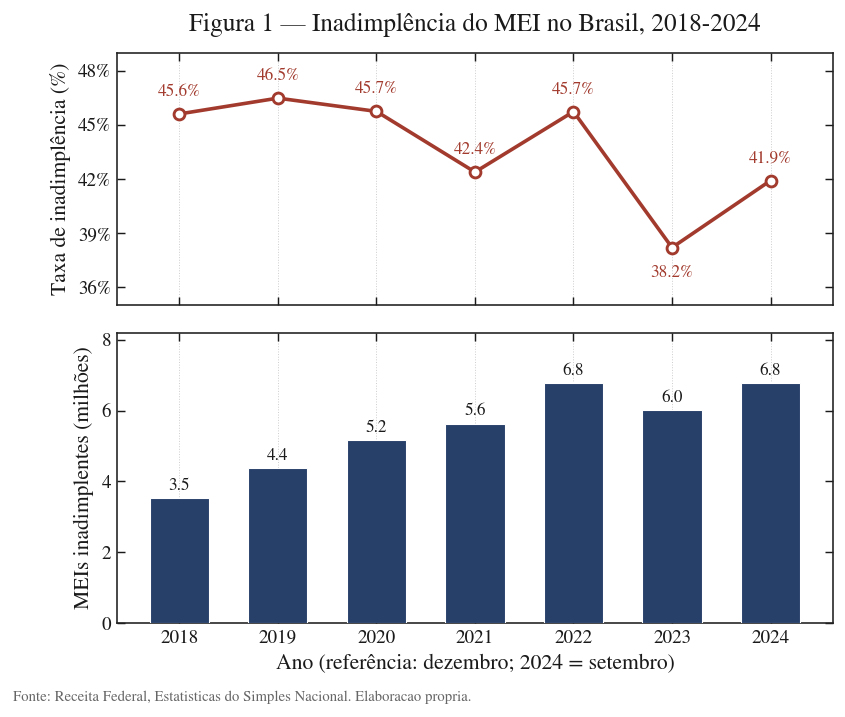

In [9]:
# =====================================================================
# FIGURA 1: dois paineis empilhados (eixo x compartilhado)
#   painel superior -> taxa de inadimplencia (linha)
#   painel inferior -> quantidade de inadimplentes (barras)
#   Layout que evita qualquer sobreposicao de rotulos.
# =====================================================================
fig, (axT, axB) = plt.subplots(
    2, 1, sharex=True, figsize=(7.1, 5.7),
    gridspec_kw={"height_ratios": [1.0, 1.15], "hspace": 0.10})

# --- painel superior: taxa (%) ---
axT.plot(x, br["taxa"], color=BRICK, marker="o", markersize=6,
         markerfacecolor="white", markeredgecolor=BRICK, markeredgewidth=1.6,
         linewidth=2.0, zorder=5)
axT.set_ylim(35, 49)
axT.yaxis.set_major_locator(mticker.MultipleLocator(3))
axT.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
axT.set_ylabel("Taxa de inadimplência (%)", color=INK)
axT.tick_params(colors=INK, right=True)
axT.grid(axis="y"); axT.set_axisbelow(True)
for xi, ti in zip(x, br["taxa"]):
    dy = 10 if ti >= 41 else -16
    axT.annotate(f"{ti:.1f}%", (xi, ti), textcoords="offset points",
                 xytext=(0, dy), ha="center", fontsize=9.5, color=BRICK, zorder=6)
axT.set_title("Figura 1 — Inadimplência do MEI no Brasil, 2018-2024", color=INK)

# --- painel inferior: quantidade (milhoes) ---
bars = axB.bar(x, br["inadimplentes"] / 1e6, width=0.60,
               color=NAVY, edgecolor="white", linewidth=0.6, zorder=3)
axB.set_ylim(0, 8.2)
axB.yaxis.set_major_locator(mticker.MultipleLocator(2))
axB.set_ylabel("MEIs inadimplentes (milhões)", color=INK)
axB.set_xlabel("Ano (referência: dezembro; 2024 = setembro)", color=INK)
axB.tick_params(colors=INK, right=True)
axB.grid(axis="y"); axB.set_axisbelow(True)
for b, v in zip(bars, br["inadimplentes"] / 1e6):
    axB.text(b.get_x() + b.get_width()/2, b.get_height() + 0.12, f"{v:.1f}",
             ha="center", va="bottom", fontsize=9.5, color=INK, zorder=4)

fig.text(0.012, 0.005, SRC, fontsize=8.2, color="#666666")
plt.savefig("fig1_inadimplencia_mei_brasil.png", bbox_inches="tight")
plt.show()



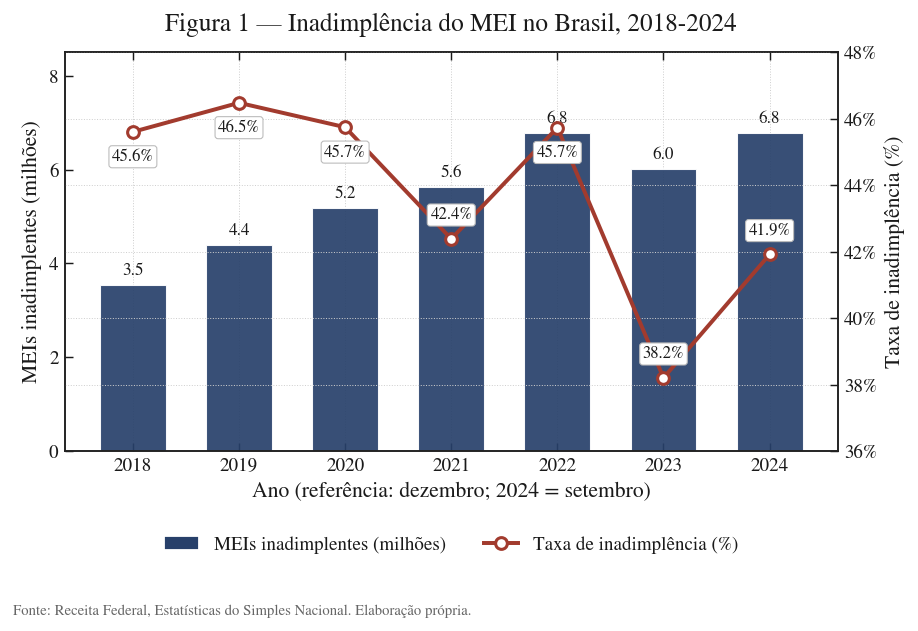

ok


In [23]:
# =====================================================================
# FIGURA 1 (versao sobreposta): barras (quantidade) + linha (taxa)
# em eixo duplo, estilo Overleaf/LaTeX minimalista. Script autossuficiente.
#   Uso no Colab: upload de "Inadimplencia_MEI_2018_2024.xlsx" e rodar.
# =====================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

ARQ = "Inadimplencia_MEI_2018_2024.xlsx"

# ---------- estilo academico (mesmo das outras figuras) ----------
serif_stack = ["CMU Serif", "STIXGeneral", "DejaVu Serif"]
try:
    font_manager.findfont("CMU Serif", fallback_to_default=False)
except Exception:
    serif_stack = ["STIXGeneral", "DejaVu Serif"]

plt.rcParams.update({
    "font.family": "serif", "font.serif": serif_stack,
    "mathtext.fontset": "cm", "axes.unicode_minus": True,
    "figure.dpi": 130, "savefig.dpi": 300, "figure.figsize": (7.1, 4.6),
    "axes.titlesize": 14, "axes.labelsize": 12,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
    "axes.spines.top": True, "axes.spines.right": True,
    "axes.edgecolor": "#222222", "axes.linewidth": 0.9,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "xtick.major.size": 4.5, "ytick.major.size": 4.5,
    "axes.grid": True, "grid.color": "#CFCFCF",
    "grid.linewidth": 0.55, "grid.linestyle": ":",
    "legend.frameon": False, "legend.fontsize": 10.5, "axes.titlepad": 12,
    "text.color": "#1A1A1A", "axes.labelcolor": "#1A1A1A",
})
INK   = "#1A1A1A"   # todo o texto (rotulos, numeros, legenda, titulo)
NAVY  = "#27406A"   # barras (quantidade) - cor so dentro do grafico
BRICK = "#A23B2E"   # linha (taxa) - cor so dentro do grafico
SRC   = "Fonte: Receita Federal, Estatísticas do Simples Nacional. Elaboração própria."

# ---------- dados ----------
df = pd.read_excel(ARQ, sheet_name="UF_serie_longa")
df["Ano"] = df["Ano"].astype(int)
br = (df.groupby("Ano")
        .agg(optantes=("Optantes MEI", "sum"),
             inadimplentes=("MEIs inadimplentes", "sum")).reset_index())
br["taxa"] = br["inadimplentes"] / br["optantes"] * 100
x = br["Ano"].astype(str)

# ---------- figura sobreposta ----------
fig, ax1 = plt.subplots()

# barras = quantidade (eixo esquerdo)
bars = ax1.bar(x, br["inadimplentes"] / 1e6, width=0.62,
               color=NAVY, edgecolor="white", linewidth=0.6, alpha=0.92, zorder=2)
ax1.set_ylim(0, 8.5)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax1.set_ylabel("MEIs inadimplentes (milhões)", color=INK)
ax1.set_xlabel("Ano (referência: dezembro; 2024 = setembro)", color=INK)
ax1.tick_params(axis="y", colors=INK)
ax1.tick_params(axis="x", colors=INK)
ax1.grid(axis="y"); ax1.set_axisbelow(True)
# rotulos de quantidade ACIMA das barras (preto)
for b, v in zip(bars, br["inadimplentes"] / 1e6):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.14, f"{v:.1f}",
             ha="center", va="bottom", fontsize=9.5, color=INK, zorder=3)

# linha = taxa (eixo direito), escala apertada para dar amplitude
ax2 = ax1.twinx()
ax2.set_ylim(36, 48)
ax2.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
ax2.set_ylabel("Taxa de inadimplência (%)", color=INK)
ax2.tick_params(axis="y", direction="in", colors=INK)
ax2.spines["right"].set_color("#222222")
ax2.plot(x, br["taxa"], color=BRICK, marker="o", markersize=6.5,
         markerfacecolor="white", markeredgecolor=BRICK, markeredgewidth=1.7,
         linewidth=2.2, zorder=6)
# rotulos da taxa em caixinha branca (texto preto); acima nos vales, abaixo nos picos
for xi, ti in zip(x, br["taxa"]):
    dy = -16 if ti >= 43 else 11
    ax2.annotate(f"{ti:.1f}%", (xi, ti), textcoords="offset points",
                 xytext=(0, dy), ha="center", fontsize=9.3, color=INK, zorder=7,
                 bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="#BBBBBB", lw=0.6))

ax1.set_title("Figura 1 — Inadimplência do MEI no Brasil, 2018-2024", color=INK)

# legenda manual (texto preto; so o simbolo carrega a cor)
leg_items = [Patch(facecolor=NAVY, edgecolor="white", label="MEIs inadimplentes (milhões)"),
             Line2D([0], [0], color=BRICK, marker="o", markerfacecolor="white",
                    markeredgecolor=BRICK, markeredgewidth=1.7, markersize=6.5,
                    linewidth=2.2, label="Taxa de inadimplência (%)")]
leg = ax1.legend(handles=leg_items, loc="upper center", bbox_to_anchor=(0.5, -0.17),
                 ncol=2, handlelength=1.8)
for txt in leg.get_texts():
    txt.set_color(INK)
fig.text(0.012, -0.04, SRC, fontsize=8.2, color="#666666")
plt.tight_layout()
plt.savefig("fig1_overlay.png", bbox_inches="tight")
plt.show()
print("ok")

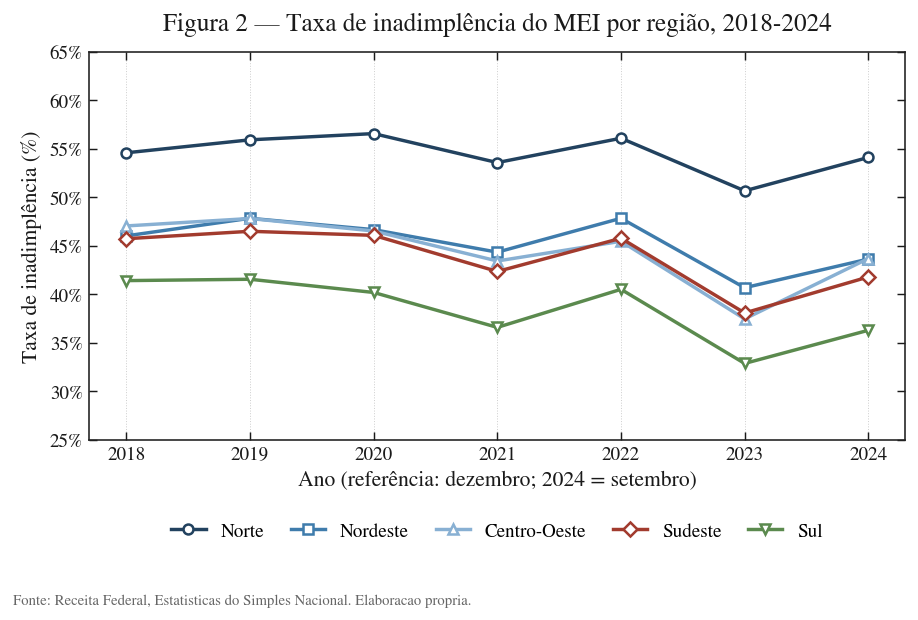

OK: fig1_inadimplencia_mei_brasil.png e fig2_inadimplencia_mei_regiao.png


In [10]:
# =====================================================================
# FIGURA 2: taxa de inadimplencia por regiao (mesmo estilo da Figura 1)
# =====================================================================
reg = (df.groupby(["Ano", "Região"])
         .agg(opt=("Optantes MEI", "sum"), inad=("MEIs inadimplentes", "sum"))
         .reset_index())
reg["taxa"] = reg["inad"] / reg["opt"] * 100
ordem = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
cores = {"Norte": "#22425F", "Nordeste": "#3F7CAC", "Centro-Oeste": "#88B0D3",
         "Sudeste": "#A23B2E", "Sul": "#5B8A4E"}
marc  = {"Norte": "o", "Nordeste": "s", "Centro-Oeste": "^", "Sudeste": "D", "Sul": "v"}

fig, ax = plt.subplots()
for r in ordem:
    s = reg[reg["Região"] == r].sort_values("Ano")
    ax.plot(s["Ano"].astype(str), s["taxa"], marker=marc[r], markersize=5.5,
            markerfacecolor="white", markeredgecolor=cores[r], markeredgewidth=1.4,
            linewidth=1.9, color=cores[r], label=r, zorder=4)
ax.set_ylim(25, 65)
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
ax.set_title("Figura 2 — Taxa de inadimplência do MEI por região, 2018-2024", color=INK)
ax.set_xlabel("Ano (referência: dezembro; 2024 = setembro)", color=INK)
ax.set_ylabel("Taxa de inadimplência (%)", color=INK)
ax.tick_params(colors=INK, right=True)
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=5,
          handlelength=1.8, columnspacing=1.4)
fig.text(0.012, -0.045, SRC, fontsize=8.2, color="#666666")
plt.tight_layout()
plt.savefig("fig2_inadimplencia_mei_regiao.png", bbox_inches="tight")
plt.show()

print("OK: fig1_inadimplencia_mei_brasil.png e fig2_inadimplencia_mei_regiao.png")